In [9]:
from calc_setup import *
import math
set_design_code('ec2_2004')


## Member Capacity Calculation

### Purlin design check

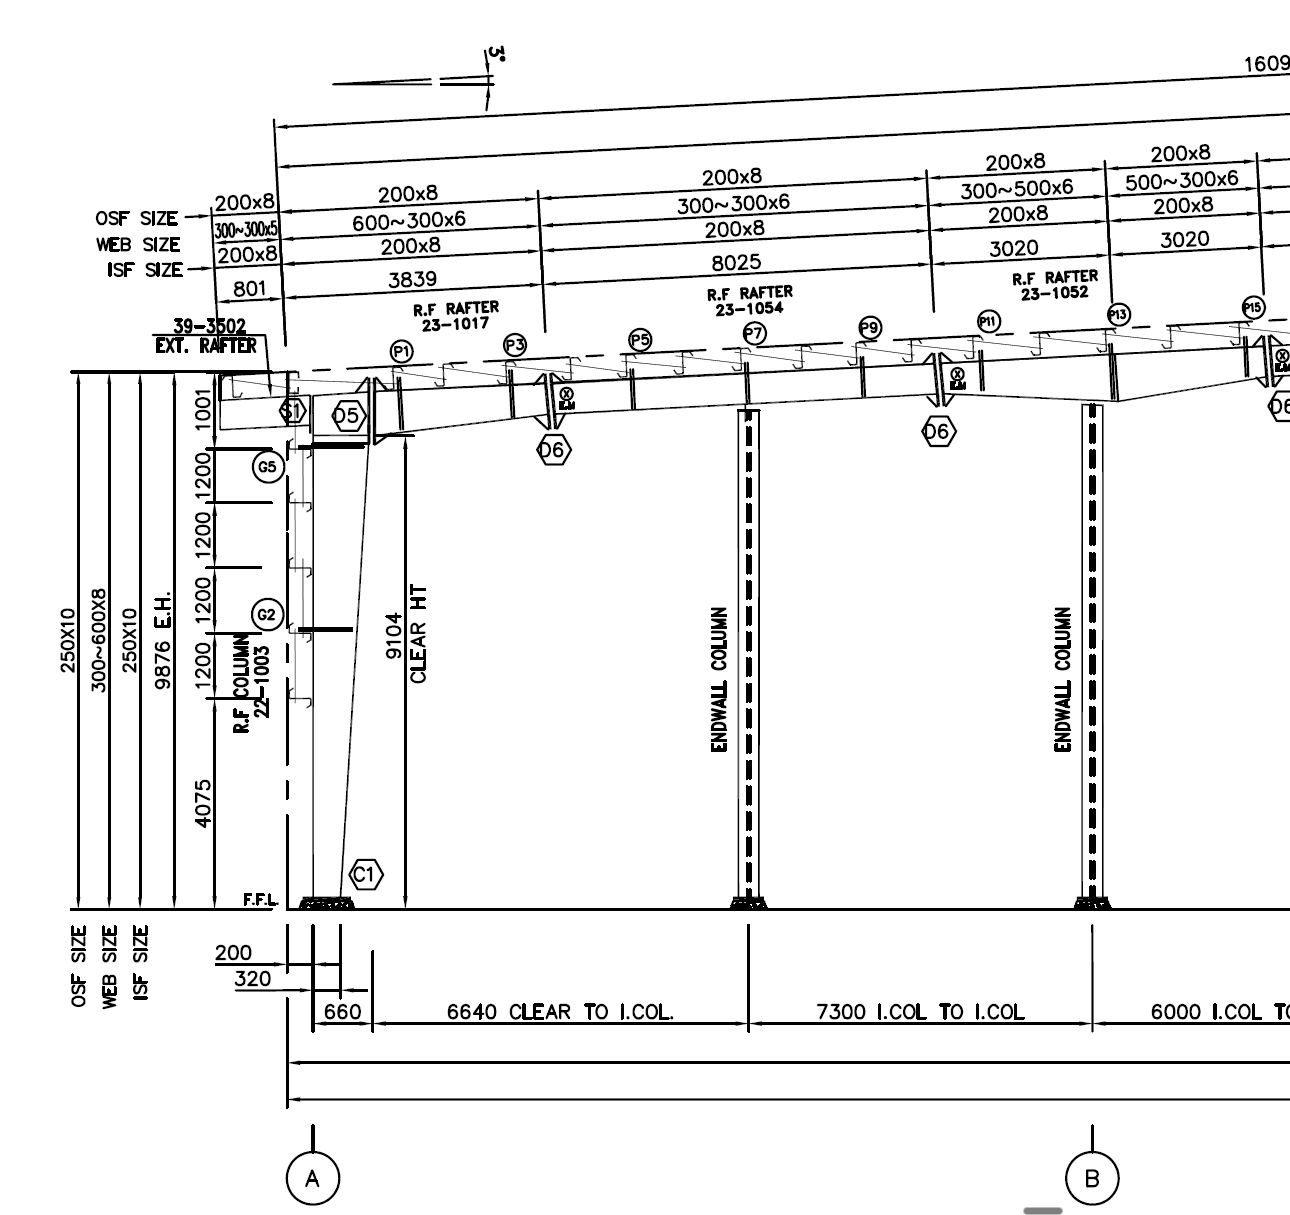

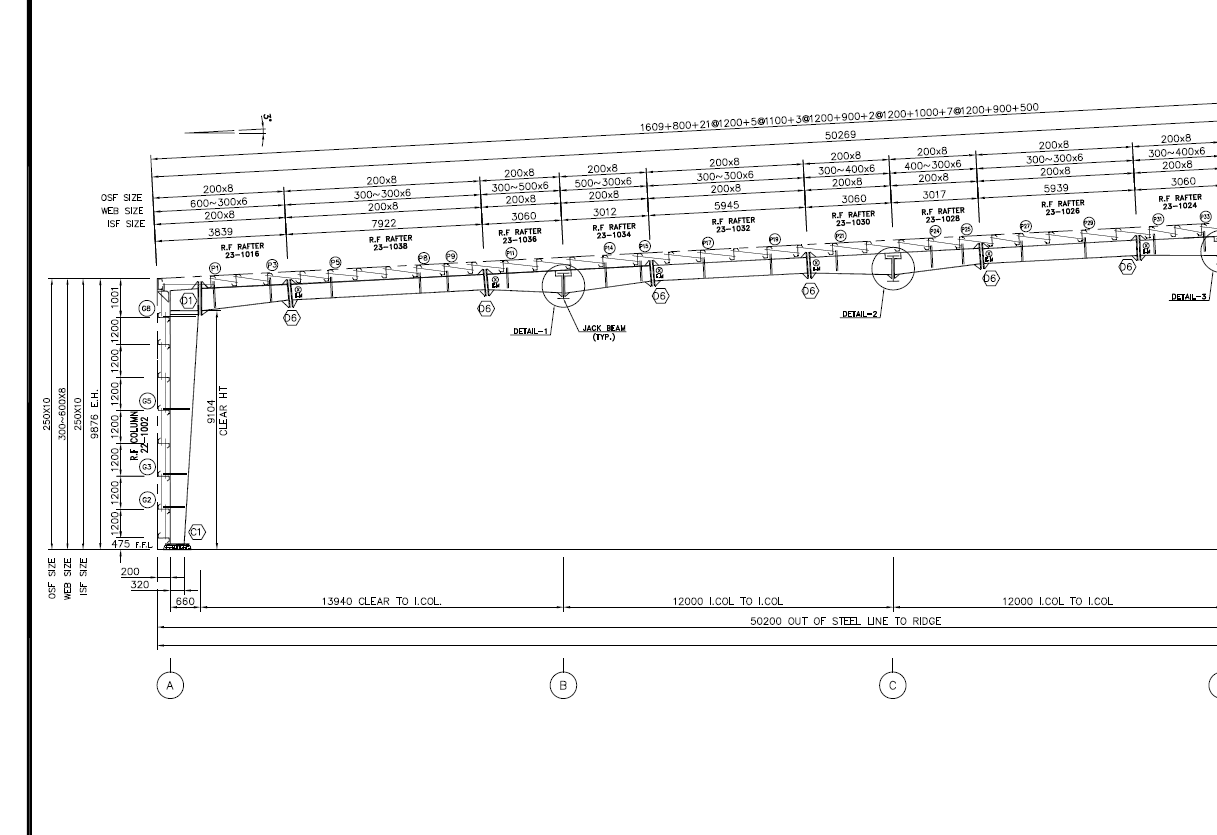

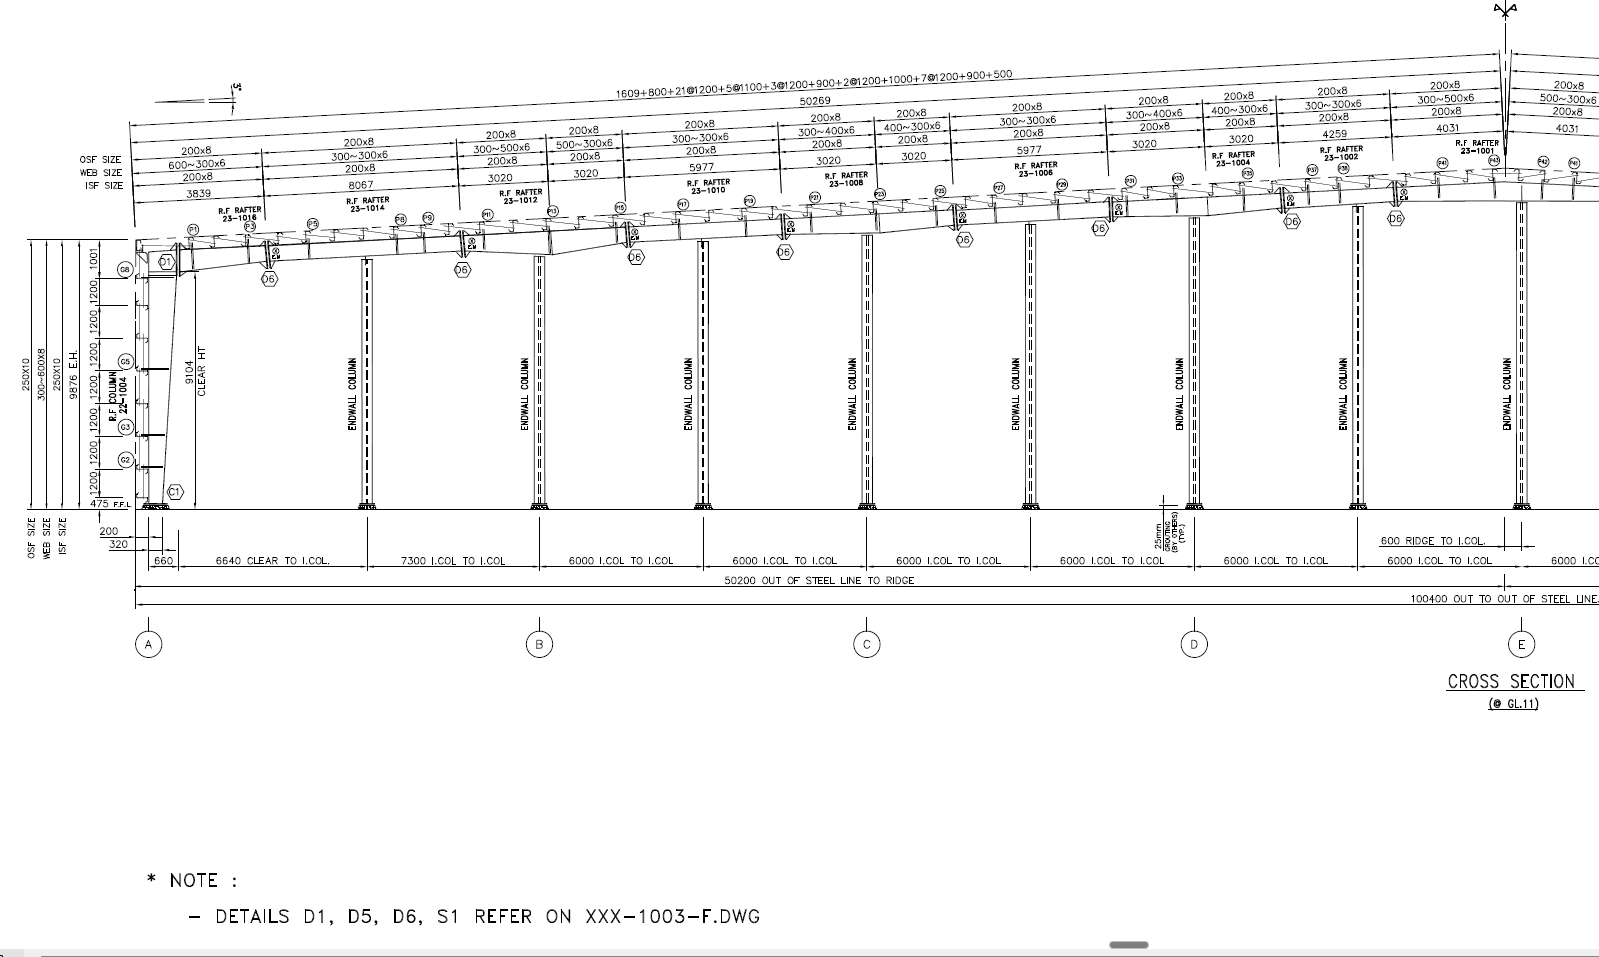

In [10]:
%%render params
# Material
fy = 450         # steel yield strength (MPa) typical steel grade is G550. using G450 for more conservative design

# Eurocode safety factors
gamma_M0 = 1.0

# Section properties (Z200x2.0 approx)
Z_cm3 = 32       # section modulus (cm3) member dedued from darwing is “PURL 200Z20 (TYP.) (UNO.)” -> Z200 × 2.0 cold-formed purlin
t = 2              # thickness (mm)
h = 200            # web depth (mm)

<IPython.core.display.Latex object>

In [11]:
%%render
# -------------------------
# UNIT CONVERSION
# -------------------------

Z = Z_cm3 * 1e3        # convert cm3 → mm3

# -------------------------
# BENDING RESISTANCE (EC3)
# -------------------------

M_Rd = (fy * Z) / (gamma_M0 * 1e6)

# -------------------------
# SHEAR RESISTANCE (EC3)
# -------------------------

A_v = t * h

V_Rd = (A_v * fy) / (math.sqrt(3) * gamma_M0) / 1000




<IPython.core.display.Latex object>

# -------------------------------------------------------
### simply supported with 1 concentrated loads
# -------------------------------------------------------

In [12]:
%%render params
L = 8.325          # span (m)
# s = 1.2          # purlin spacing (m)
P = 1.5       # each point load (kN)
P_ult = P * 1.5 # factored load (kN)


# -------------------------------------------------------

<IPython.core.display.Latex object>

In [13]:
%%render
R = P_ult / 2
M_max = P_ult * L / 4

<IPython.core.display.Latex object>

In [14]:
%%render
# -------------------------
# UTILISATION
# -------------------------

UR_bending = M_max / M_Rd # <1 hence bending Pass

UR_shear = R / V_Rd # <1 hence shear Pass

<IPython.core.display.Latex object>

## Connection design check

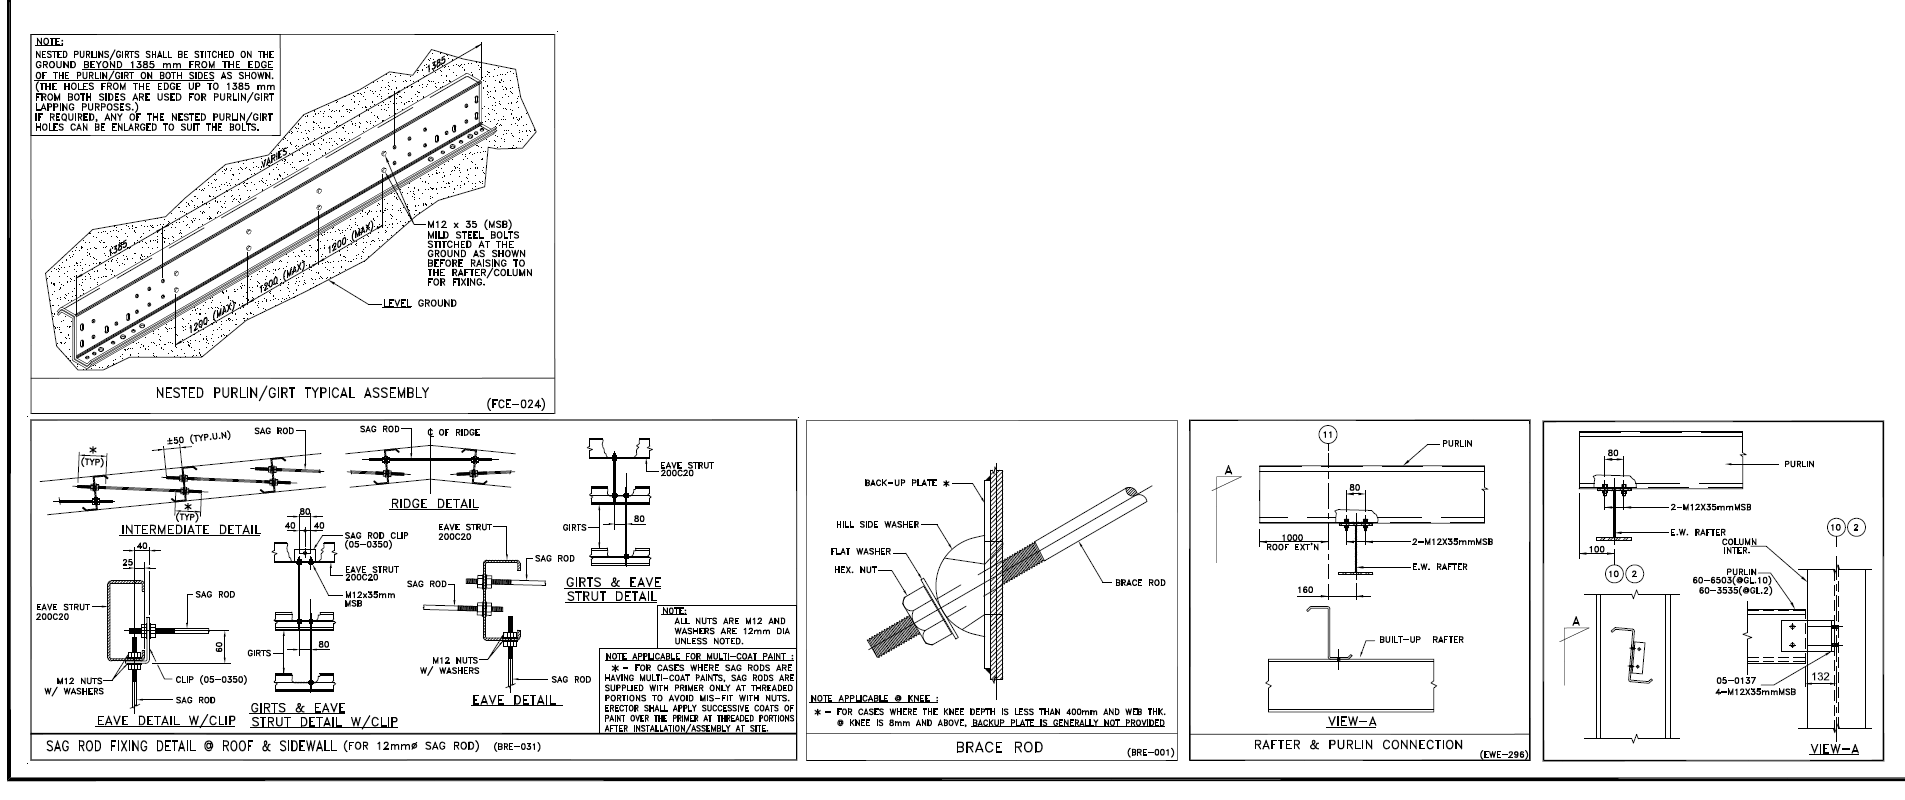

In [15]:
%%render params
# -------------------------------------------------
# INPUT PARAMETERS
# -------------------------------------------------

# Geometry
L = 6.0            # purlin span (m)""
s = 0.6            # purlin spacing (m)

# Loading
q = 0.6            # roof load (kN/m2)
wind_uplift = 1.2  # wind suction (kN/m2)

# Bolt properties
d = 12             # bolt diameter (mm)
A_b = 84.3         # bolt tensile area (mm2)


<IPython.core.display.Latex object>

In [16]:
%%render params
f_ub = 400         # bolt ultimate strength (MPa)
gamma_M2 = 1.25    # EC3 bolt partial factor
alpha_v = 0.6      # shear factor

# Purlin properties
t = 2              # purlin thickness (mm)
f_u = 550          # ultimate steel strength (MPa)

# Connection
n_bolts = 2        # number of bolts

<IPython.core.display.Latex object>

In [17]:
%%render

# -------------------------------------------------
# BOLT SHEAR RESISTANCE (EN 1993-1-8)
# -------------------------------------------------

V_b_Rd = (alpha_v * f_ub * A_b) / (gamma_M2 * 1000)

V_connection_Rd = n_bolts * V_b_Rd

# -------------------------------------------------
# BOLT TENSION RESISTANCE
# -------------------------------------------------

N_b_Rd = (0.9 * f_ub * A_b) / (gamma_M2 * 1000)

N_connection_Rd = n_bolts * N_b_Rd

# -------------------------------------------------
# BOLT BEARING RESISTANCE ON PURLIN
# -------------------------------------------------

F_b_Rd = (2.5 * d * t * f_u) / (gamma_M2 * 1000)

F_b_connection_Rd = n_bolts * F_b_Rd

# -------------------------------------------------
# UTILISATION
# -------------------------------------------------

UR_shear = R / V_connection_Rd # connection Pass, shear failure mode

UR_tension = R / N_connection_Rd # connection Pass, tension failure mode

UR_bearing = R / F_b_connection_Rd # connection Pass, bearing failure mode

<IPython.core.display.Latex object>